# Signal Preprocessing

[Classification of ECG Using Ensemble of Residual CNNs with Attention Mechanism](https://ieeexplore.ieee.org/document/9662723)

1. Provided data are expanded into fixed 12-lead configuration. If any lead is missing, the particular matrix row is filled with zeroes. This transformation always outputs a matrix with dimensions (12, time).
2. Resampling: Data are resampled to the sampling frequency of 500 Hz. Polyphase filtering is used when the original sampling frequency is 1000 Hz; otherwise, the FFT method is used for resampling.
3. Filtering: Data are filtered using a zero-phase method with 3rd order Butterworth bandpass filter with frequency band from 1 Hz to 47 Hz.
4. Normalization: Each ECG channel is normalized using a z-score.
5. Zeropadding: Data are zero-padded into the shape of 8192 samples in the time domain. If a signal length is larger than 8192, then the signal is randomly sampled and cut into the length of 8192.
6. Augmentation: During the training phase, randomly choose the lead configuration (e.g. 12, 6, 4, 3, 2). Leads that are not used are filled with zeros.

In [2]:
import os
import wfdb
import numpy as np
from scipy import signal
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [3]:
os.chdir('..')

In [20]:
sig = wfdb.rdrecord('cinc-2021_data/training/cpsc_2018/g4/A3034')
sig_pulse_raw = sig.p_signal[:,0][:600]

print(f"frequency: {sig.fs} Hz")

frequency: 500 Hz


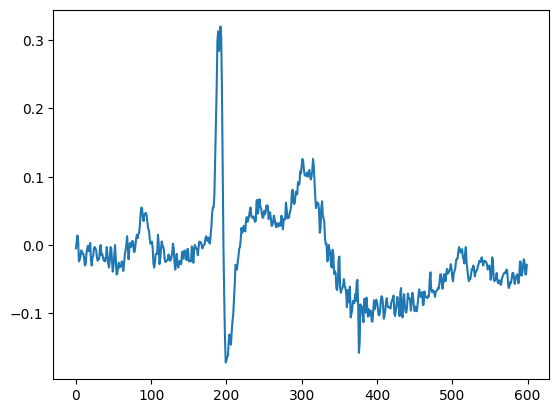

In [21]:
plt.plot(sig_pulse_raw)

## Butterworth bandpass filter

- Order: 3
- Bandpass Range: 1 Hz ... 47 Hz
- Sample Rate: 500 Hz

In [28]:
b, a = signal.butter(3, [1 / 250, 47 / 250], 'bandpass')
sig_pulse_butter = signal.filtfilt(b, a, sig_pulse_raw)

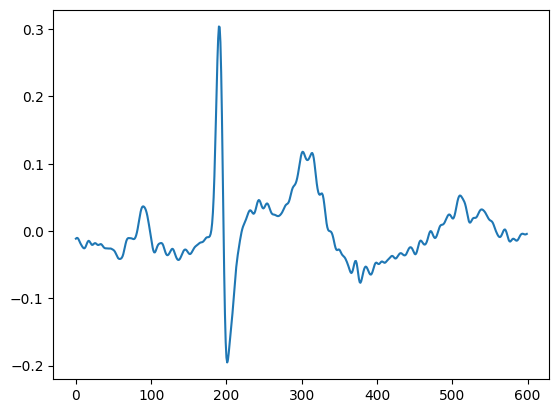

In [23]:
plt.plot(sig_pulse_butter)

In [24]:
sig_pulse_zscore = zscore(sig_pulse_butter, axis=-1)

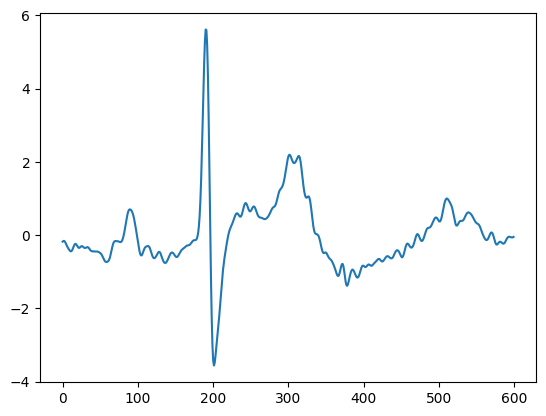

In [25]:
plt.plot(sig_pulse_zscore)

# Preprocessing from [Classification of ECG Using Ensemble of Residual CNNs with Attention Mechanism](https://ieeexplore.ieee.org/document/9662723)

In [12]:
def zero_padding(x):
    y = np.zeros((12, 8192))
    if x.shape[1]<8192:
        y[:,-x.shape[1]:] = x
    else:
        y = x[:,:8192]
    return y

In [13]:
def preprocessing(recording, fs):
    b, a= signal.butter(N=3, Wn=(1 / 250, 47 / 250), btype='bandpass', output='ba')

    if fs > 500:
        recording = signal.resample_poly(recording, up=1, down=2, axis=-1) # to 500Hz
    elif fs < 500:
        recording = signal.resample(recording, int(recording.shape[1] * 500 / fs), axis=1)

    recording = signal.filtfilt(b, a, recording)
    recording = zscore(recording, axis=-1)
    recording = np.nan_to_num(recording)
    recording = zero_padding(recording)
    return recording

## 500 Hz signal
chapman_shaoxing

In [ ]:
sig_500Hz = wfdb.rdrecord('cinc-2021_data/training/chapman_shaoxing/g4/A3034')

## 257 Hz signal
st_petersburg_incart

In [ ]:
sig_257Hz = wfdb.rdrecord('cinc-2021_data/training/st_petersburg_incart/g4/A3034')

## 1000 Hz signal
ptb

In [19]:
signal_1000Hz = wfdb.rdrecord('cinc-2021_data/training/ptb/g1/S0047').p_signal
signal_1000Hz = np.transpose(signal_1000Hz)
preprocessed_signal_1000Hz = preprocessing(signal_1000Hz, 1000)


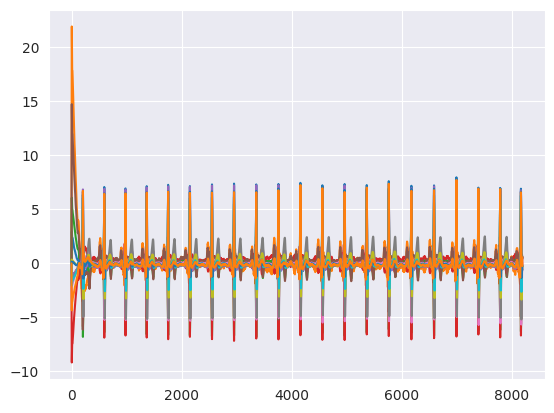

In [24]:
for sig in preprocessed_signal_1000Hz:
    plt.plot(sig)

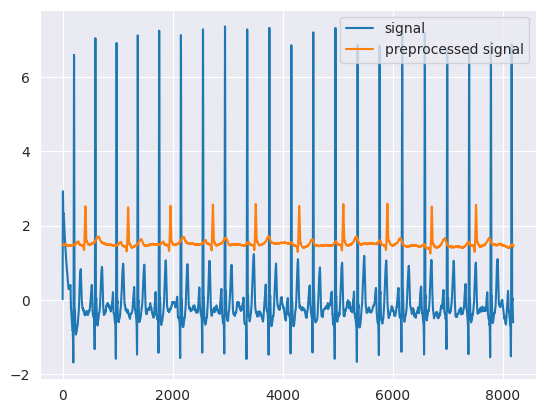

In [33]:
i = 0
plt.plot(preprocessed_signal_1000Hz[i], label='signal')
plt.plot(signal_1000Hz[i][:8200], label='preprocessed signal')
plt.legend()